# Notebook 09: Análisis Semántico con Word2Vec
## Representaciones vectoriales estáticas sobre letras musicales

**Proyecto:** Análisis Morfosintáctico de Letras Musicales  
**Referencia metodológica:** Lab BoW – Word2Vec – BETO (Osvaldo González Chaves)

---

### Objetivo
Aplicar Word2Vec para explorar el espacio semántico del corpus musical:

| Análisis | Descripción |
|----------|-------------|
| 1 | Preprocesamiento y tokenización desde pos_tags |
| 2 | Entrenamiento CBOW y Skip-Gram (corpus global) |
| 3 | Vecinos semánticos y analogías vectoriales |
| 4 | Similitud entre géneros (centroides) |
| 5 | Modelos por género: vocabulario contextual |
| 6 | Vocabulario exclusivo por género |

> *"Los embeddings aparecen como los pesos aprendidos de la red neuronal"*  
> — Presentación Semana 10


---
## 1. Imports y configuración

In [16]:
import warnings, os
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import spacy
import sys
sys.path.append(os.path.abspath('../../../../../..'))
from src.data.mongo_storage import _get_default_collection
from pymongo import UpdateOne

FIGS   = Path('../../../../../..') / 'data' / 'figures'
MODELS = Path('../../../../../..') / 'data' / 'models'
for d in [FIGS, MODELS]: d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print('✓ Imports OK')


✓ Imports OK


In [17]:
import subprocess, sys, spacy

# Instalar el modelo si no está disponible
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Descargando en_core_web_sm...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
                   check=True)
    nlp = spacy.load('en_core_web_sm')

STOPWORDS = nlp.Defaults.stop_words
print(f"✓ spaCy cargado — {len(STOPWORDS)} stopwords")

✓ spaCy cargado — 326 stopwords


---
## 2. Cargar corpus desde MongoDB

In [18]:
col = _get_default_collection()

docs = list(col.find(
    {'pos_tags.spacy': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1,
     'Song year': 1, 'pos_tags': 1}
))
df = pd.DataFrame(docs)
df = df.dropna(subset=['Genre']).copy()

df['pos_tags_spacy'] = df['pos_tags'].apply(
    lambda x: x.get('spacy', []) if isinstance(x, dict) else []
)
df = df[df['pos_tags_spacy'].apply(len) > 0].reset_index(drop=True)

conteo = df['Genre'].value_counts()
generos_validos = conteo[conteo >= 20].index.tolist()
df = df[df['Genre'].isin(generos_validos)].reset_index(drop=True)

print(f'✓ {len(df):,} canciones | {df["Genre"].nunique()} géneros')
print(df['Genre'].value_counts().to_string())


✓ 7,935 canciones | 10 géneros
Genre
Rock          1410
Pop           1110
Hip-Hop        960
Metal          810
Country        810
Jazz           660
Electronic     660
Indie          510
R&B            510
Folk           495


---
## 3. Tokenización y limpieza desde pos_tags

### ¿Por qué limpiar antes de entrenar?

Word2Vec aprende relaciones entre tokens en su vocabulario.  
Si el corpus contiene tokens ruidosos (`ahhhhhh`, `cashcashcash`, `staaaaay`),  
el modelo aprende relaciones **entre ruido**, no entre conceptos.

**Solución:** filtrar usando los campos POS ya guardados en MongoDB.


In [19]:
import re
import spacy

nlp = spacy.load('en_core_web_sm')
STOPWORDS = nlp.Defaults.stop_words  # ~326 stopwords en inglés

# Patrones de fragmentos de contracciones y ruido léxico frecuente en letras
# Ej: "didn", "sayhow", "ppose", "meand", "yeahah", "ill" (I'll), etc.
PATRON_FRAGMENTO = re.compile(
    r"^(didn|couldn|wouldn|shouldn|won|don|isn|aren|wasn|weren|haven|hadn"
    r"|aint|wont|cant|gon|cause|ill|em|im|ur|ya|yer|ol|th|ve|re|ll|nd|nt)$"
)

def tokens_limpios(pos_tags: list) -> list:
    """
    Extrae lemas limpios desde pos_tags de MongoDB.

    Excluye:
      - Puntuación, espacios, símbolos, números, miscelánea (PUNCT/SPACE/SYM/NUM/X)
      - Nombres propios (PROPN): artistas, lugares, nombres en letras
      - Stopwords del inglés
      - Tokens de menos de 3 caracteres
      - Tokens con caracteres repetidos 4+ veces (onomatopeyas: ahhhhh, staaay)
      - Fragmentos de contracciones (didn, couldn, ill, gon, cause…)
      - Tokens con dígitos embebidos (mp3, 2pac-style artifacts)
    """
    tokens = []
    for t in pos_tags:
        # Filtrar por categoría gramatical
        if t.get('pos') in ('PUNCT', 'SPACE', 'SYM', 'NUM', 'X', 'PROPN'):
            continue
        lemma = t.get('lemma', '').lower().strip()

        # Longitud mínima
        if not lemma or len(lemma) < 3:
            continue

        # Stopwords
        if lemma in STOPWORDS:
            continue

        # Caracteres repetidos (onomatopeyas / ruido)
        if re.search(r'(.)\\1{3,}', lemma):
            continue

        # Fragmentos de contracciones y ruido léxico
        if PATRON_FRAGMENTO.match(lemma):
            continue

        # Tokens con dígitos embebidos (artefactos)
        if re.search(r'\\d', lemma):
            continue

        tokens.append(lemma)
    return tokens


df['tokens_w2v'] = df['pos_tags_spacy'].apply(tokens_limpios)
corpus_tokens    = df['tokens_w2v'].tolist()

total  = sum(len(t) for t in corpus_tokens)
unicos = len(set(t for toks in corpus_tokens for t in toks))

print(f'✓ {total:,} tokens totales | {unicos:,} lemas únicos')
print()
todas = [t for toks in corpus_tokens for t in toks]
top20 = Counter(todas).most_common(20)
print('Top 20 tokens más frecuentes (verificación de calidad):')
for tok, n in top20:
    print(f'  {tok:<20} {n:>6}')


✓ 673,963 tokens totales | 26,270 lemas únicos

Top 20 tokens más frecuentes (verificación de calidad):
  know                  12276
  love                  12106
  like                  11172
  come                   7711
  time                   6729
  want                   5957
  let                    5356
  way                    4961
  feel                   4916
  tell                   4707
  yeah                   4347
  day                    4180
  think                  4173
  baby                   3985
  life                   3951
  heart                  3882
  right                  3764
  look                   3640
  need                   3530
  night                  3460


---
## 4. Entrenar Word2Vec — CBOW y Skip-Gram (corpus global)

### Diferencia entre arquitecturas

| Arquitectura | Tarea | Mejor para |
|---|---|---|
| **CBOW** | Predice la palabra central dado el contexto | Palabras frecuentes |
| **Skip-Gram** | Predice el contexto dada la palabra central | Palabras raras, más lento |

Entrenamos ambas con los mismos hiperparámetros para comparar resultados.


In [20]:
print('Entrenando Word2Vec CBOW (global)...')
w2v_cbow = Word2Vec(
    corpus_tokens,
    vector_size=100,   # dimensión de los embeddings
    window=5,          # contexto: 5 palabras a cada lado
    min_count=5,       # mínimo 5 apariciones para incluir en vocabulario
    sg=0,              # sg=0 → CBOW
    epochs=20,
    seed=42,
    workers=4,
)
print(f'   CBOW      — vocabulario: {len(w2v_cbow.wv):,} palabras')

print('Entrenando Word2Vec Skip-Gram (global)...')
w2v_sg = Word2Vec(
    corpus_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,              # sg=1 → Skip-Gram
    epochs=20,
    seed=42,
    workers=4,
)
print(f'   Skip-Gram — vocabulario: {len(w2v_sg.wv):,} palabras')

w2v_cbow.save(str(MODELS / 'w2v_cbow.model'))
w2v_sg.save(str(MODELS / 'w2v_skipgram.model'))
print()
print('✓ Modelos globales guardados en disco')


Entrenando Word2Vec CBOW (global)...
   CBOW      — vocabulario: 7,354 palabras
Entrenando Word2Vec Skip-Gram (global)...
   Skip-Gram — vocabulario: 7,354 palabras

✓ Modelos globales guardados en disco


---
## 5. Exploración: vecinos semánticos

Comprobamos que las palabras más cercanas en el espacio vectorial son **semánticamente coherentes**.  
Este es el test cualitativo básico de que el modelo aprendió bien.


In [21]:
print('=== Vecinos semánticos — Skip-Gram global ===')
print('(Palabras en contexto musical; deben ser semánticamente coherentes)\n')

palabras_test = ['love', 'fight', 'night', 'money', 'soul', 'fire', 'road', 'dark']

for palabra in palabras_test:
    if palabra in w2v_sg.wv:
        vecinos = w2v_sg.wv.most_similar(palabra, topn=5)
        vstr = ', '.join([f'{w} ({s:.2f})' for w, s in vecinos])
        print(f'  {palabra:<10} → {vstr}')
    else:
        print(f'  {palabra:<10} → no está en vocabulario (min_count=5)')

print()
print('Verificar: ¿los vecinos tienen sentido semántico en el contexto musical?')


=== Vecinos semánticos — Skip-Gram global ===
(Palabras en contexto musical; deben ser semánticamente coherentes)

  love       → turtledove (0.70), sayhow (0.68), somekind (0.67), know (0.65), superfine (0.61)
  fight      → truce (0.61), fret (0.56), unsung (0.54), suppress (0.54), threat (0.53)
  night      → rendezvous (0.62), strobe (0.60), camper (0.60), dutty (0.59), sleepless (0.57)
  money      → ayy (0.65), cash (0.60), funny (0.58), baloney (0.57), duffle (0.57)
  soul       → dancin (0.59), captor (0.58), control (0.58), massacre (0.58), selfesteem (0.57)
  fire       → alight (0.64), blinding (0.60), desire (0.60), burning (0.58), afire (0.58)
  road       → blacktop (0.56), enlighten (0.56), reservation (0.54), bumpy (0.54), lug (0.52)
  dark       → light (0.62), brightness (0.57), blinding (0.55), taime (0.54), shadow (0.53)

Verificar: ¿los vecinos tienen sentido semántico en el contexto musical?


---
## 6. Analogías vectoriales

La propiedad más famosa de Word2Vec:  
**rey − hombre + mujer ≈ reina**

Esto funciona porque las relaciones semánticas se codifican como **direcciones** en el espacio vectorial.

> Si la analogía falla, generalmente es porque alguna de las palabras tiene poco contexto en el corpus,  
> no porque el modelo sea incorrecto.


In [22]:
def analogia(positivos, negativos, modelo, top_n=3, excluir_input=True):
    """
    Resuelve: ¿qué palabra resulta de positivos - negativos?
    Retorna las top_n más cercanas al vector resultante.
    """
    ausentes = [w for w in positivos + negativos if w not in modelo.wv]
    if ausentes:
        return None, ausentes
    resultados = modelo.wv.most_similar(
        positive=positivos,
        negative=negativos,
        topn=top_n + len(positivos) + len(negativos)
    )
    excluir = set(positivos + negativos) if excluir_input else set()
    resultados = [(w, s) for w, s in resultados if w not in excluir]
    return resultados[:top_n], []


print('=== Analogías vectoriales (Skip-Gram global) ===')
print('Formato: positivos - negativos → resultado esperado\n')

analogias = [
    (['love', 'happy'],    ['sad'],      'love + happy − sad    → (emoción positiva)'),
    (['night', 'dark'],    ['day'],      'night + dark − day    → (oscuridad nocturna)'),
    (['king'],             ['man'],      'king − man            → (concepto sin género)'),
    (['king', 'woman'],    ['man'],      'king − man + woman    → (queen esperada)'),
    (['jazz', 'trumpet'],  ['guitar'],   'jazz − guitar + trumpet'),
    (['dance', 'music'],   ['silence'],  'dance + music − silence'),
    (['broken', 'heart'],  ['happy'],    'broken + heart − happy'),
]

for pos, neg, desc in analogias:
    res, ausentes = analogia(pos, neg, w2v_sg)
    print(f'  {desc}')
    if ausentes:
        print(f'    ⚠ Palabras fuera de vocabulario: {ausentes}')
    else:
        for w, s in res:
            print(f'    → {w} ({s:.3f})')
    print()


=== Analogías vectoriales (Skip-Gram global) ===
Formato: positivos - negativos → resultado esperado

  love + happy − sad    → (emoción positiva)
    → somekind (0.540)
    → unconditional (0.523)
    → turtledove (0.506)

  night + dark − day    → (oscuridad nocturna)
    → light (0.552)
    → constellation (0.503)
    → harness (0.490)

  king − man            → (concepto sin género)
    → queen (0.344)
    → peasant (0.335)
    → fairytale (0.265)

  king − man + woman    → (queen esperada)
    → queen (0.432)
    → sheik (0.401)
    → echo (0.392)

  jazz − guitar + trumpet
    → alpha (0.459)
    → angelic (0.458)
    → reconcile (0.456)

  dance + music − silence
    → wen (0.557)
    → jig (0.497)
    → hardwood (0.492)

  broken + heart − happy
    → devastate (0.529)
    → dissect (0.514)
    → hearted (0.506)



---
## 7. Similitud entre géneros (vectores centroide)

Calculamos el vector promedio (centroide) de cada género  
y medimos la similitud coseno entre pares.

> **Nota importante:** Los embeddings promediados tienden a colapsar en un espacio denso,  
> haciendo que todos los géneros sean muy similares (>0.90).  
> Esto es una limitación conocida de Word2Vec con promediado simple.  
> Por eso usamos también los modelos por género (sección 9).


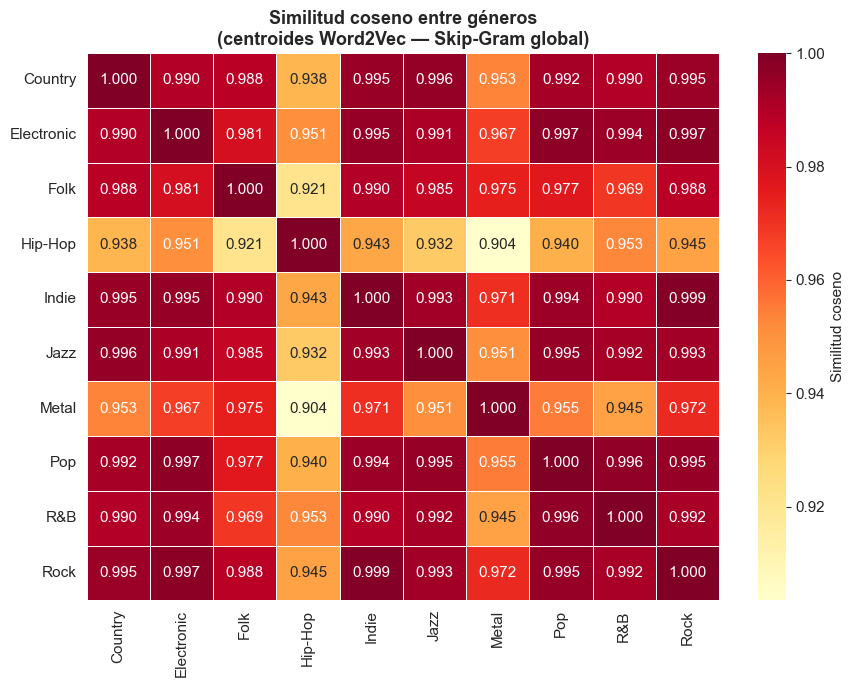


Top 3 pares más SIMILARES:
  Indie ↔ Rock: 0.9990
  Electronic ↔ Rock: 0.9971
  Electronic ↔ Pop: 0.9969

Top 3 pares más DIFERENTES:
  Hip-Hop ↔ Jazz: 0.9323
  Folk ↔ Hip-Hop: 0.9212
  Hip-Hop ↔ Metal: 0.9035

Observación: similitudes altas (>0.90) son esperables con promediado simple.
Ver sección 9 para comparación inter-género a nivel de vocabulario.


In [23]:
# Calcular centroide por género usando el modelo global
centroides = {}
for genero in generos_validos:
    tokens_g = [t for toks in df[df['Genre'] == genero]['tokens_w2v'] for t in toks]
    vecs = [w2v_sg.wv[t] for t in tokens_g if t in w2v_sg.wv]
    if vecs:
        centroides[genero] = np.mean(vecs, axis=0)

generos_ord = sorted(centroides.keys())
n = len(generos_ord)
sim_matrix = np.zeros((n, n))
for i, g1 in enumerate(generos_ord):
    for j, g2 in enumerate(generos_ord):
        sim_matrix[i, j] = 1 - cosine(centroides[g1], centroides[g2])

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(n, dtype=bool)
vmin = sim_matrix[~mask].min()

sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=generos_ord, yticklabels=generos_ord,
            vmin=vmin, vmax=1.0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Similitud coseno'})
ax.set_title('Similitud coseno entre géneros\n(centroides Word2Vec — Skip-Gram global)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'w2v_similitud_generos.png', dpi=150, bbox_inches='tight')
plt.show()

# Top similares y diferentes
print()
pares = [(sim_matrix[i,j], generos_ord[i], generos_ord[j])
         for i in range(n) for j in range(i+1, n)]
pares.sort(reverse=True)

print('Top 3 pares más SIMILARES:')
for s, g1, g2 in pares[:3]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')

print('\nTop 3 pares más DIFERENTES:')
for s, g1, g2 in pares[-3:]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')

print()
print('Observación: similitudes altas (>0.90) son esperables con promediado simple.')
print('Ver sección 9 para comparación inter-género a nivel de vocabulario.')


---
## 8. Proyección t-SNE de embeddings

Proyectamos los embeddings de palabras clave a 2 dimensiones  
para visualizar si los clusters semánticos son coherentes.


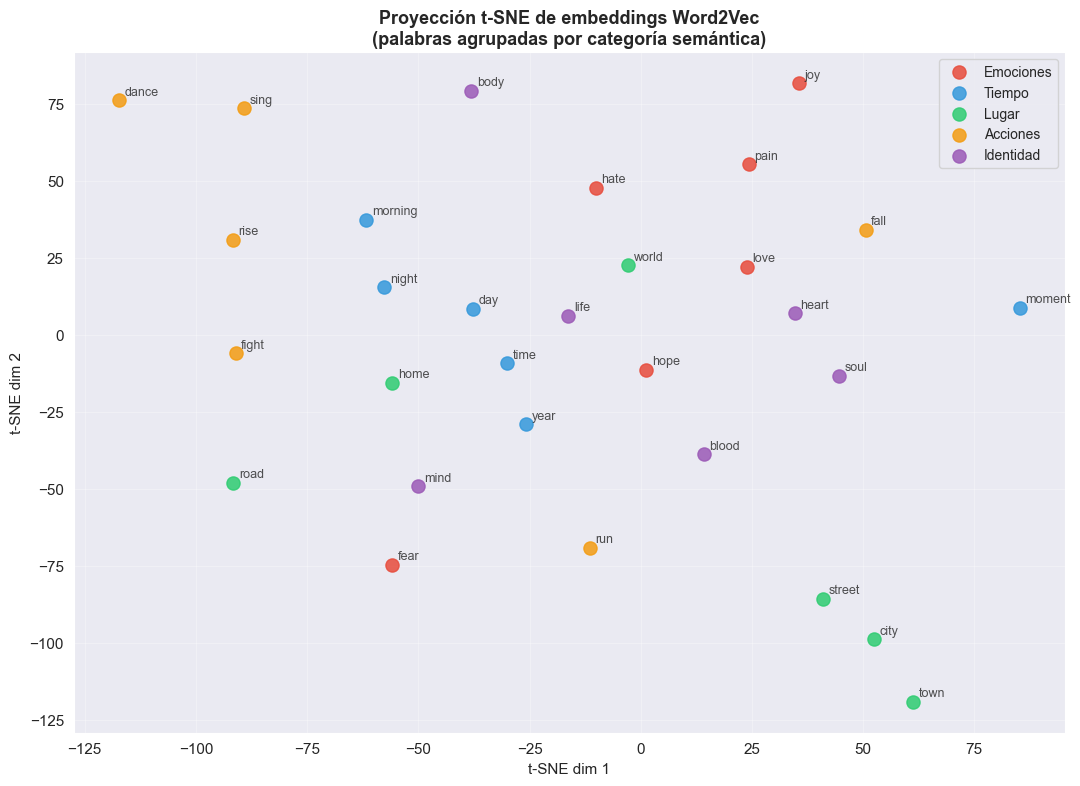

Verificar: ¿las palabras del mismo grupo semántico aparecen cerca?


In [24]:
grupos = {
    'Emociones':   ['love', 'hate', 'fear', 'joy', 'pain', 'hope'],
    'Tiempo':      ['night', 'day', 'morning', 'year', 'time', 'moment'],
    'Lugar':       ['road', 'street', 'home', 'town', 'city', 'world'],
    'Acciones':    ['fight', 'run', 'dance', 'sing', 'fall', 'rise'],
    'Identidad':   ['heart', 'soul', 'mind', 'body', 'life', 'blood'],
}

colores_grupos = {
    'Emociones':  '#e74c3c',
    'Tiempo':     '#3498db',
    'Lugar':      '#2ecc71',
    'Acciones':   '#f39c12',
    'Identidad':  '#9b59b6',
}

palabras_plot, vectores_plot, categorias_plot = [], [], []

for cat, palabras in grupos.items():
    for p in palabras:
        if p in w2v_sg.wv:
            palabras_plot.append(p)
            vectores_plot.append(w2v_sg.wv[p])
            categorias_plot.append(cat)

if len(vectores_plot) >= 5:
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=min(5, len(vectores_plot)-1))
    coords = tsne.fit_transform(np.array(vectores_plot))

    fig, ax = plt.subplots(figsize=(11, 8))
    for cat in grupos.keys():
        idxs = [i for i, c in enumerate(categorias_plot) if c == cat]
        ax.scatter(coords[idxs, 0], coords[idxs, 1],
                   color=colores_grupos[cat], s=90, label=cat, alpha=0.85, zorder=3)
        for i in idxs:
            ax.annotate(palabras_plot[i],
                        (coords[i, 0], coords[i, 1]),
                        fontsize=9, alpha=0.8,
                        xytext=(4, 4), textcoords='offset points')

    ax.set_title('Proyección t-SNE de embeddings Word2Vec\n'
                 '(palabras agrupadas por categoría semántica)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    plt.tight_layout()
    plt.savefig(FIGS / 'w2v_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Verificar: ¿las palabras del mismo grupo semántico aparecen cerca?')
else:
    print('⚠ Pocas palabras en vocabulario para t-SNE. Reducir min_count.')


---
## 9. Modelos Word2Vec por género

Entrenamos un modelo independiente por género.  
Esto permite comparar cómo **la misma palabra** tiene vecinos distintos  
según el contexto musical del género.


In [25]:
modelos_genero = {}

for genero in generos_validos:
    tokens_g = df[df['Genre'] == genero]['tokens_w2v'].tolist()
    n_canciones = len(tokens_g)
    n_tokens = sum(len(t) for t in tokens_g)

    if n_canciones < 10 or n_tokens < 500:
        print(f'  {genero:<12} — muy pocas canciones/tokens, saltando')
        continue

    modelo_g = Word2Vec(
        tokens_g,
        vector_size=100,
        window=5,
        min_count=3,  # min_count más bajo para géneros con menos canciones
        sg=1,
        epochs=20,
        seed=42,
        workers=4,
    )
    modelos_genero[genero] = modelo_g
    modelo_g.save(str(MODELS / f'w2v_{genero.replace("-","_").lower()}.model'))
    print(f'  ✓ {genero:<12} — {len(modelo_g.wv):,} palabras | {n_canciones} canciones')

print(f'\n✓ {len(modelos_genero)} modelos por género entrenados y guardados')


  ✓ Rock         — 3,033 palabras | 1410 canciones
  ✓ Pop          — 2,571 palabras | 1110 canciones
  ✓ Hip-Hop      — 5,058 palabras | 960 canciones
  ✓ Metal        — 2,892 palabras | 810 canciones
  ✓ Country      — 1,986 palabras | 810 canciones
  ✓ Jazz         — 1,865 palabras | 660 canciones
  ✓ Electronic   — 1,997 palabras | 660 canciones
  ✓ Indie        — 1,658 palabras | 510 canciones
  ✓ R&B          — 1,604 palabras | 510 canciones
  ✓ Folk         — 1,946 palabras | 495 canciones

✓ 10 modelos por género entrenados y guardados


---
## 10. Vecinos de la misma palabra por género

La misma palabra tiene **vecinos distintos** según el modelo del género.  
Esto muestra que el **contexto de uso varía** entre géneros musicales.


In [26]:
PALABRAS_COMP = ['love', 'night', 'fire', 'road']

for palabra in PALABRAS_COMP:
    print(f'=== "{palabra}" — vecinos por género ===')
    encontrado_en = 0
    for genero, modelo_g in modelos_genero.items():
        if palabra not in modelo_g.wv:
            continue
        encontrado_en += 1
        vecinos = modelo_g.wv.most_similar(palabra, topn=4)
        vstr = ', '.join([w for w, _ in vecinos])
        print(f'  {genero:<12} → {vstr}')
    if encontrado_en == 0:
        print(f'  ⚠ Palabra no encontrada en ningún modelo de género (min_count=3)')
    print()


=== "love" — vecinos por género ===
  Rock         → tenderly, agonna, peacefully, complication
  Pop          → symmetrical, fck, indian, want
  Hip-Hop      → ppose, spending, complicated, marmalade
  Metal        → frenchfrye, peacock, steak, frenchfrie
  Country      → understanding, eternally, certain, lasting
  Jazz         → turtledove, sacrifice, overdue, tenderly
  Electronic   → ahahhhh, want, heart, darlin
  Indie        → stole, gaga, beyonce, despair
  R&B          → need, pure, nuff, sayhow
  Folk         → leaving, tug, united, resist

=== "night" — vecinos por género ===
  Rock         → excited, leprechaun, coastline, popular
  Pop          → sleepless, dazzling, shooting, bame
  Hip-Hop      → surprising, morning, noon, nighy
  Metal        → sleepless, hopeful, scarlet, moon
  Country      → divine, jeannie, softly, spotlight
  Jazz         → seventh, middle, gone, dawn
  Electronic   → woohoo, ppose, beating, parasite
  Indie        → linger, lucky, fun, blurry
  R&

---
## 11. Vocabulario exclusivo por género

Identificamos palabras cuyo vector en el modelo global  
está **más cerca del centroide de un género que de todos los demás**.  
Estas palabras son características de ese género.


In [27]:
def palabras_exclusivas(genero_objetivo, top_k=10):
    """
    Busca palabras en el vocabulario global cuyo vector esté
    más cerca del centroide del género objetivo.
    """
    if genero_objetivo not in centroides:
        return []
    c_obj   = centroides[genero_objetivo]
    c_otros = [c for g, c in centroides.items() if g != genero_objetivo]

    resultados = []
    for palabra in w2v_sg.wv.index_to_key:
        vec = w2v_sg.wv[palabra]
        sim_obj   = 1 - cosine(vec, c_obj)
        sim_otros = max(1 - cosine(vec, c) for c in c_otros)
        margen    = sim_obj - sim_otros
        if margen > 0:
            resultados.append((palabra, round(sim_obj, 4), round(margen, 4)))

    resultados.sort(key=lambda x: -x[2])
    return resultados[:top_k]


print('=== Vocabulario exclusivo por género (Top 10) ===\n')
vocab_exclusivo = {}
for genero in generos_validos:
    excl = palabras_exclusivas(genero, top_k=10)
    vocab_exclusivo[genero] = excl
    palabras_str = ', '.join([p for p, _, _ in excl])
    print(f'  {genero:<12} → {palabras_str}')


=== Vocabulario exclusivo por género (Top 10) ===

  Rock         → attraction, avenue, seriously, blame, look, disconnect, concerned, pretend, confidence, mutual
  Pop          → complicated, realise, perfect, lasting, closely, loves, forever, eachother, hold, thankful
  Hip-Hop      → shittin, rookie, beotch, jockin, choppa, pokin, gutta, semi, stackin, stuffin
  Metal        → condemn, damnation, morbid, wickedness, hellish, vector, cult, carrion, infest, degenerate
  Country      → rodeo, motel, mornin, bronc, town, cowboy, postcard, rambler, tan, railroad
  Jazz         → embraceable, wonderful, indiscreet, sweet, romance, beyonce, captivate, honeysuckle, bopbadomp, irreplaceable
  Electronic   → energy, domino, malfunction, evacuate, dive, motion, robot, stop, unlock, noise
  Indie        → chew, awkward, disappear, asleep, raining, diary, hint, bedroom, gig, plaster
  R&B          → baby, reunion, mistreat, shiftin, freakydicky, depressed, dontcha, hearsay, kiddio, yeah
  Folk  

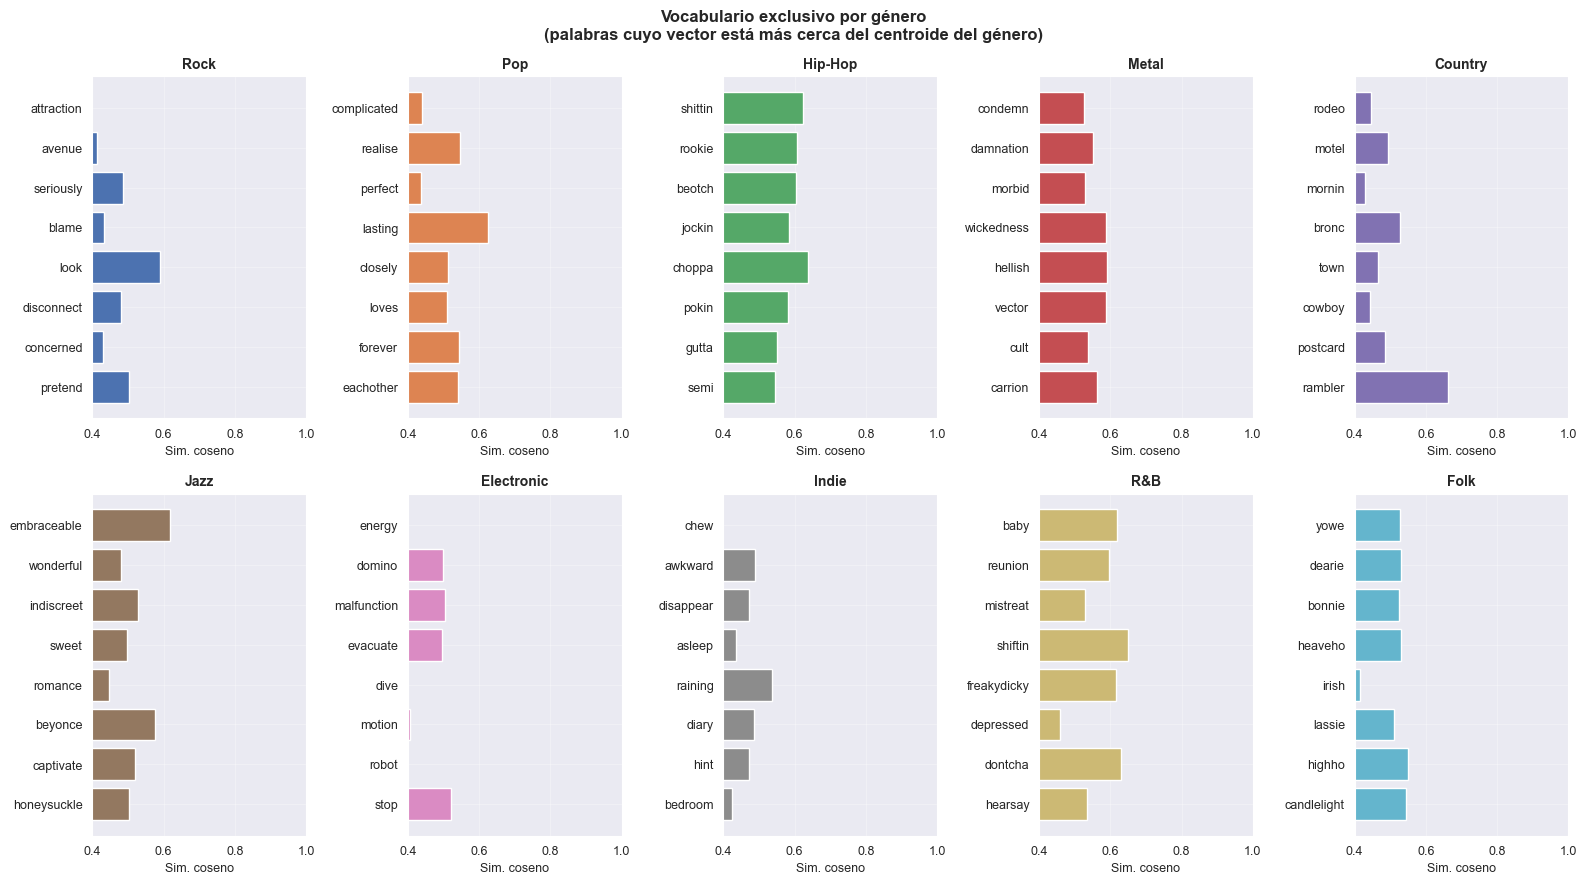

In [28]:
# Visualización: barras de similitud coseno por género
n_g = len(generos_validos)
fig, axes = plt.subplots(2, (n_g + 1) // 2,
                          figsize=((n_g + 1) // 2 * 3.2, 9))
axes = axes.flatten()

for ax, genero in zip(axes, generos_validos):
    datos  = vocab_exclusivo.get(genero, [])[:8]
    if not datos:
        ax.axis('off')
        continue
    pals   = [d[0] for d in datos]
    scores = [d[1] for d in datos]
    color  = PALETTE[generos_validos.index(genero) % len(PALETTE)]
    ax.barh(pals[::-1], scores[::-1], color=color, edgecolor='white')
    ax.set_title(genero, fontsize=10, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel('Sim. coseno', fontsize=9)
    ax.tick_params(labelsize=9)

# Ocultar ejes sobrantes
for ax in axes[n_g:]:
    ax.axis('off')

plt.suptitle('Vocabulario exclusivo por género\n'
             '(palabras cuyo vector está más cerca del centroide del género)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'w2v_vocab_exclusivo.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Guardar embeddings en MongoDB

In [29]:
# Guardar embeddings Word2Vec en MongoDB
# Usa update_one + $set para NO pisar campos existentes (bert_cls, metricas, etc.)
# Solo actualiza embeddings.word2vec_avg

from pymongo import UpdateOne

print('Guardando embeddings Word2Vec en MongoDB...')
print('Estrategia: $set solo sobre embeddings.word2vec_avg')
print()

def w2v_promedio(tokens, modelo):
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    return np.mean(vecs, axis=0).tolist() if vecs else None

operaciones = []
sin_vector  = 0

for _, row in df.iterrows():
    emb = w2v_promedio(row['tokens_w2v'], w2v_sg)
    if emb is None:
        sin_vector += 1
        continue
    operaciones.append(
        UpdateOne(
            {'_id': row['_id']},
            {'$set': {'embeddings.word2vec_avg': emb}},
            upsert=False   # nunca crear documentos nuevos
        )
    )

# Ejecutar en lotes de 500 para no saturar la conexión
LOTE = 500
guardados = 0
errores   = 0

for i in range(0, len(operaciones), LOTE):
    lote = operaciones[i : i + LOTE]
    try:
        resultado = col.bulk_write(lote, ordered=False)
        guardados += resultado.modified_count
    except Exception as e:
        errores += len(lote)
        print(f'  ⚠ Error en lote {i//LOTE + 1}: {e}')
    done = min(i + LOTE, len(operaciones))
    print(f'\r  {done}/{len(operaciones)} operaciones enviadas — modificados: {guardados}',
          end='', flush=True)

print()
print(f'\n✓ embeddings.word2vec_avg actualizado: {guardados}/{len(df)} canciones')
if sin_vector:
    print(f'  Canciones sin vector (tokens fuera de vocab): {sin_vector}')
if errores:
    print(f'  ⚠ Errores: {errores} operaciones fallidas')

# Verificación rápida: leer un doc y confirmar que el campo existe
sample = col.find_one(
    {'_id': df.iloc[0]['_id']},
    {'embeddings.word2vec_avg': 1}
)
if sample and sample.get('embeddings', {}).get('word2vec_avg'):
    dim = len(sample['embeddings']['word2vec_avg'])
    print(f'  Verificación OK — dimensión del vector almacenado: {dim}')
else:
    print('  ⚠ Verificación fallida — revisar conexión a MongoDB')


Guardando embeddings Word2Vec en MongoDB...
Estrategia: $set solo sobre embeddings.word2vec_avg

  7935/7935 operaciones enviadas — modificados: 7935

✓ embeddings.word2vec_avg actualizado: 7935/7935 canciones
  Verificación OK — dimensión del vector almacenado: 100


---
## 13. Resumen

In [30]:
print('=' * 60)
print('  RESUMEN — Word2Vec')
print('=' * 60)
print(f'  Corpus         : {len(df):,} canciones | {len(generos_validos)} géneros')
print(f'  Vocabulario    : {len(w2v_sg.wv):,} lemas únicos (Skip-Gram global)')
print(f'  Modelos        : 1 global (CBOW + Skip-Gram) + {len(modelos_genero)} por género')
print()
print('  Archivos generados:')
for f in sorted(MODELS.glob('w2v_*.model')):
    print(f'    {f.name}')
print()
print('  CONCLUSIONES:')
print('  • Limpieza de tokens elimina ruido onomatopéyico del corpus musical')
print('  • Modelos por género capturan vocabulario y contexto propios')
print('  • La misma palabra tiene vecinos distintos según el género')
print('  • Vocabulario exclusivo identifica términos característicos por género')
print('  • Alta similitud entre centroides es limitación del promediado simple')
print('  • Los embeddings word2vec_avg quedaron guardados en MongoDB')
print('=' * 60)


  RESUMEN — Word2Vec
  Corpus         : 7,935 canciones | 10 géneros
  Vocabulario    : 7,354 lemas únicos (Skip-Gram global)
  Modelos        : 1 global (CBOW + Skip-Gram) + 10 por género

  Archivos generados:
    w2v_cbow.model
    w2v_country.model
    w2v_electronic.model
    w2v_folk.model
    w2v_hip_hop.model
    w2v_indie.model
    w2v_jazz.model
    w2v_metal.model
    w2v_pop.model
    w2v_r&b.model
    w2v_rock.model
    w2v_skipgram.model

  CONCLUSIONES:
  • Limpieza de tokens elimina ruido onomatopéyico del corpus musical
  • Modelos por género capturan vocabulario y contexto propios
  • La misma palabra tiene vecinos distintos según el género
  • Vocabulario exclusivo identifica términos característicos por género
  • Alta similitud entre centroides es limitación del promediado simple
  • Los embeddings word2vec_avg quedaron guardados en MongoDB
